Pipeline:-

Semi supervised learning. So far PCA and Variance thresholding with correlation filter too didn't work really well using iForest so one final shot by giving it features from already well performing supervised Learning model i.e XGBoost.

In [ ]:
import numpy as np
import pandas as pd
import copy
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    precision_score, recall_score, f1_score, accuracy_score
)
import gc
import matplotlib.ticker as mticker
import copy

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
file_paths = [
    r"/content/drive/MyDrive/MachineLearningCVE/Monday-WorkingHours.pcap_ISCX.csv",
    r"/content/drive/MyDrive/MachineLearningCVE/Tuesday-WorkingHours.pcap_ISCX.csv",
    r"/content/drive/MyDrive/MachineLearningCVE/Wednesday-workingHours.pcap_ISCX.csv",
    r"/content/drive/MyDrive/MachineLearningCVE/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv",
    r"/content/drive/MyDrive/MachineLearningCVE/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv",
    r"/content/drive/MyDrive/MachineLearningCVE/Friday-WorkingHours-Morning.pcap_ISCX.csv",
    r"/content/drive/MyDrive/MachineLearningCVE/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv",
    r"/content/drive/MyDrive/MachineLearningCVE/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv"
]

all_chunks = []

for path in file_paths:
    print(f"Loading: {path}")
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip()
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.dropna(inplace=True)
    fcols = df.select_dtypes('float64').columns
    df[fcols] = df[fcols].astype('float32')
    icols = df.select_dtypes('int64').columns
    for col in icols:
        if df[col].max() < 255:
            df[col] = df[col].astype(np.uint8)
        elif df[col].max() < 65535:
            df[col] = df[col].astype(np.uint16)
        else:
            df[col] = df[col].astype(np.uint32)

    all_chunks.append(df)
    print(f"Memory saved for this chunk. Current size: {df.memory_usage().sum() / 1024**2:.2f} MB")

#  Merge everything together
print("Combining all files into one DataFrame...")
cd = pd.concat(all_chunks, ignore_index=True)

#  Clear the temporary list to free up the "double" memory
del all_chunks
gc.collect()

#  Final step: Convert Label to binary (0 for Benign, 1 for Attack)
# Using uint8 for the label saves a massive amount of space over int64
cd['Label'] = (cd['Label'].str.strip() != 'BENIGN').astype(np.uint8)

print("--- FINISHED ---")
print(f"Final Row Count: {len(cd)}")
print(f"Final Memory Usage: {cd.memory_usage().sum() / 1024**2:.2f} MB")

Loading: /content/drive/MyDrive/MachineLearningCVE/Monday-WorkingHours.pcap_ISCX.csv
Memory saved for this chunk. Current size: 129.27 MB
Loading: /content/drive/MyDrive/MachineLearningCVE/Tuesday-WorkingHours.pcap_ISCX.csv
Memory saved for this chunk. Current size: 107.10 MB
Loading: /content/drive/MyDrive/MachineLearningCVE/Wednesday-workingHours.pcap_ISCX.csv
Memory saved for this chunk. Current size: 167.48 MB
Loading: /content/drive/MyDrive/MachineLearningCVE/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Memory saved for this chunk. Current size: 67.11 MB
Loading: /content/drive/MyDrive/MachineLearningCVE/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Memory saved for this chunk. Current size: 41.24 MB
Loading: /content/drive/MyDrive/MachineLearningCVE/Friday-WorkingHours-Morning.pcap_ISCX.csv
Memory saved for this chunk. Current size: 46.24 MB
Loading: /content/drive/MyDrive/MachineLearningCVE/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Memory saved

In [ ]:
print(len(cd))

2827876


In [ ]:
top_30_features = [
    'Bwd Packet Length Max',        # 1  — 0.1862
    'Min Packet Length',            # 2  — 0.1473
    'Bwd Packet Length Min',        # 3  — 0.1181
    'Total Length of Fwd Packets',  # 4  — 0.0853
    'Bwd Packets/s',                # 5  — 0.0638
    'Destination Port',             # 6  — 0.0599
    'Fwd Packet Length Mean',       # 7  — 0.0557
    'min_seg_size_forward',         # 8  — 0.0398
    'URG Flag Count',               # 9  — 0.0185
    'Down/Up Ratio',                # 10 — 0.0184
    'PSH Flag Count',               # 11 — 0.0168
    'Idle Min',                     # 12 — 0.0165
    'Fwd Packet Length Max',        # 13 — 0.0156
    'Bwd Header Length',            # 14 — 0.0156
    'Fwd Header Length',            # 15 — 0.0139
    'Bwd Packet Length Mean',       # 16 — 0.0135
    'Init_Win_bytes_backward',      # 17 — 0.0130
    'Idle Std',                     # 18 — 0.0111
    'Fwd Packet Length Std',        # 19 — 0.0108
    'act_data_pkt_fwd',             # 20 — 0.0104
    'Fwd PSH Flags',                # 21 — 0.0079
    'Init_Win_bytes_forward',       # 22 — 0.0068
    'Bwd Packet Length Std',        # 23 — 0.0057
    'Packet Length Variance',       # 24 — 0.0045
    'Packet Length Std',            # 25 — 0.0044
    'Active Min',                   # 26 — 0.0040
    'Bwd IAT Total',                # 27 — 0.0037
    'Fwd Packet Length Min',        # 28 — 0.0037
    'Fwd IAT Std',                  # 29 — 0.0036
    'Total Backward Packets',       # 30 — 0.0033
]

IF_CONFIGS={
    "Model A":IsolationForest(n_estimators=100, max_samples=256, contamination=0.2,random_state=42),
    "Model B":IsolationForest(n_estimators=500, max_samples=512, contamination=0.2,random_state=42),
    "Model C":IsolationForest(n_estimators=500, max_samples=256, contamination=0.2,random_state=42)
}

N= 5 | Model A | AUC=0.4748 | F1=0.2245
N= 5 | Model B | AUC=0.4868 | F1=0.2474
N= 5 | Model C | AUC=0.4846 | F1=0.2236
N= 6 | Model A | AUC=0.5067 | F1=0.2078
N= 6 | Model B | AUC=0.4720 | F1=0.1936
N= 6 | Model C | AUC=0.4777 | F1=0.1895
N= 7 | Model A | AUC=0.4770 | F1=0.1945
N= 7 | Model B | AUC=0.4847 | F1=0.2022
N= 7 | Model C | AUC=0.4779 | F1=0.1889
N= 8 | Model A | AUC=0.4968 | F1=0.1995
N= 8 | Model B | AUC=0.5262 | F1=0.2248
N= 8 | Model C | AUC=0.5310 | F1=0.2534
N= 9 | Model A | AUC=0.4999 | F1=0.1947
N= 9 | Model B | AUC=0.4845 | F1=0.1425
N= 9 | Model C | AUC=0.4711 | F1=0.1309
N=10 | Model A | AUC=0.5269 | F1=0.1980
N=10 | Model B | AUC=0.5198 | F1=0.1777
N=10 | Model C | AUC=0.5171 | F1=0.1714
N=11 | Model A | AUC=0.5472 | F1=0.1936
N=11 | Model B | AUC=0.5736 | F1=0.2292
N=11 | Model C | AUC=0.5716 | F1=0.2287
N=12 | Model A | AUC=0.6576 | F1=0.3993
N=12 | Model B | AUC=0.6655 | F1=0.4138
N=12 | Model C | AUC=0.6620 | F1=0.4078
N=13 | Model A | AUC=0.6338 | F1=0.3521


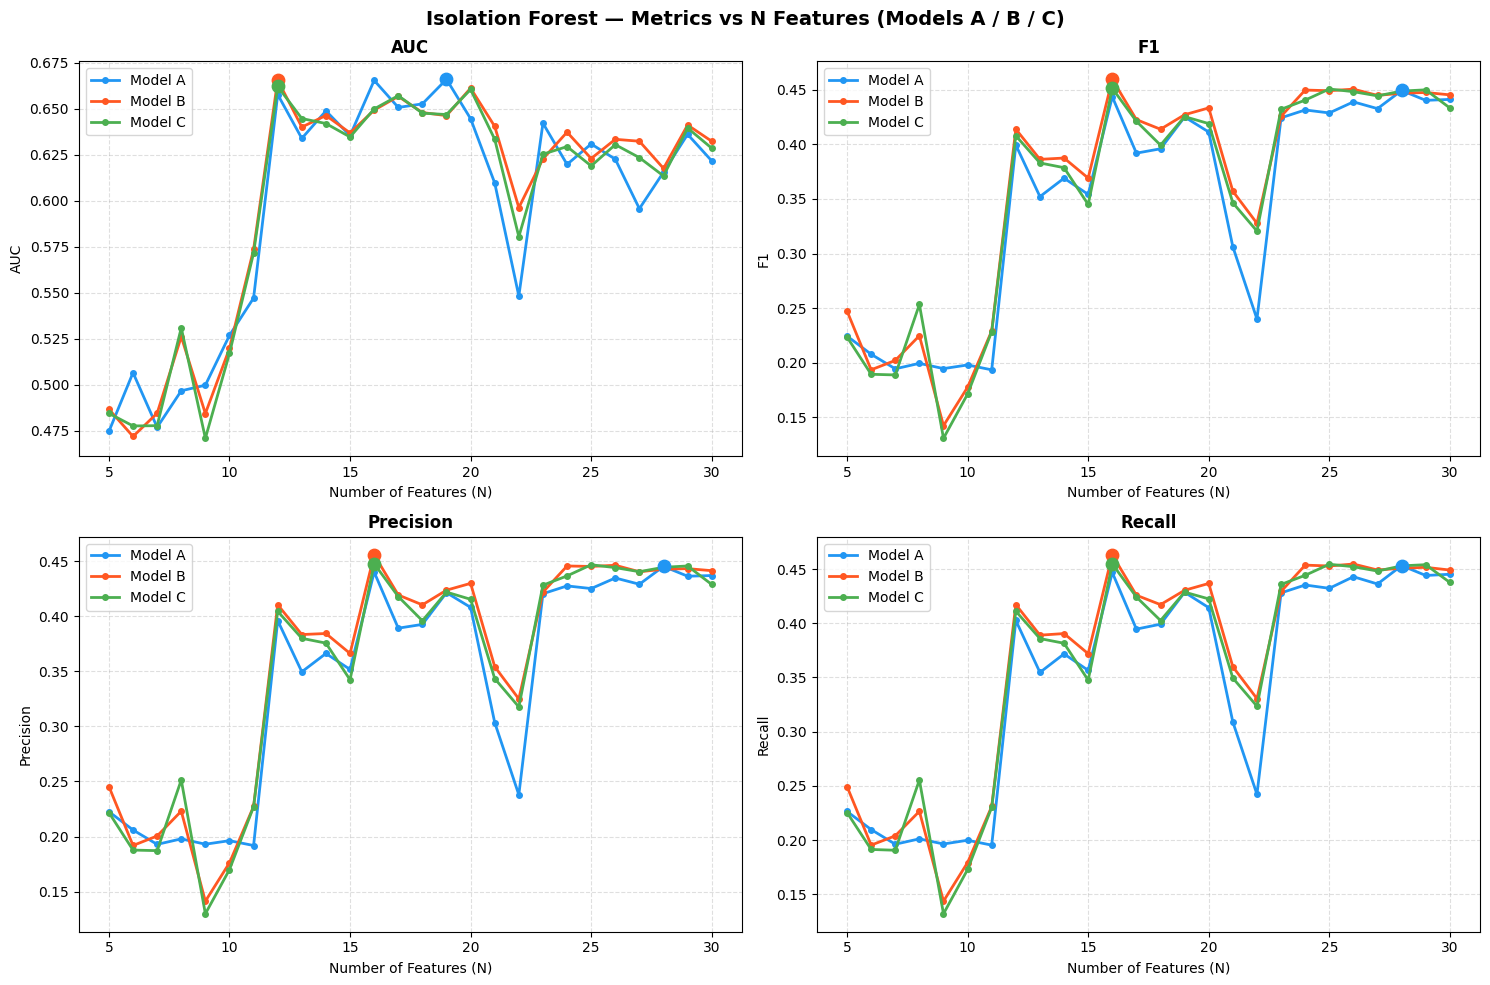


── Best N per Model ──

  AUC:
    Model A → N=19  (0.6659)
    Model B → N=12  (0.6655)
    Model C → N=12  (0.6620)

  F1:
    Model A → N=28  (0.4493)
    Model B → N=16  (0.4595)
    Model C → N=16  (0.4513)

  Precision:
    Model A → N=28  (0.4454)
    Model B → N=16  (0.4559)
    Model C → N=16  (0.4478)

  Recall:
    Model A → N=28  (0.4533)
    Model B → N=16  (0.4632)
    Model C → N=16  (0.4548)


In [ ]:
results = []

for N in range(5, 31):

    # ── Build & scale ONE split, use it, then delete it ──
    X = cd[top_30_features[:N]].copy()
    y = cd['Label']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    del X, y                          # free the full-N column copy

    scaler    = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s  = scaler.transform(X_test)
    del X_train, X_test, scaler       # free unscaled arrays

    # ── Run all 3 models on this split ──
    for if_name, if_base in IF_CONFIGS.items():
        model  = copy.deepcopy(if_base)
        model.fit(X_train_s)

        scores = -model.decision_function(X_test_s)
        preds  = (model.predict(X_test_s) == -1).astype(int)

        results.append({
            'N'        : N,
            'Model'    : if_name,
            'AUC'      : roc_auc_score(y_test, scores),
            'F1'       : f1_score(y_test, preds, zero_division=0),
            'Precision': precision_score(y_test, preds, zero_division=0),
            'Recall'   : recall_score(y_test, preds, zero_division=0),
        })
        print(f"N={N:2d} | {if_name} | AUC={results[-1]['AUC']:.4f} | F1={results[-1]['F1']:.4f}")

    # ── Drop the split before next N ──
    del X_train_s, X_test_s, y_test
    gc.collect()

results_df = pd.DataFrame(results)

# ── Plot ──────────────────────────────────────────────────────────────────────
metrics = ['AUC', 'F1', 'Precision', 'Recall']
colors  = {'Model A': '#2196F3', 'Model B': '#FF5722', 'Model C': '#4CAF50'}

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Isolation Forest — Metrics vs N Features (Models A / B / C)',
             fontsize=14, fontweight='bold')

for ax, metric in zip(axes.flatten(), metrics):
    for model_name, grp in results_df.groupby('Model'):
        ax.plot(grp['N'], grp[metric],
                marker='o', markersize=4, linewidth=2,
                label=model_name, color=colors[model_name])
        best_idx = grp[metric].idxmax()
        best_n   = grp.loc[best_idx, 'N']
        best_val = grp.loc[best_idx, metric]
        ax.scatter(best_n, best_val, s=80, zorder=5, color=colors[model_name])

    ax.set_title(metric, fontweight='bold')
    ax.set_xlabel('Number of Features (N)')
    ax.set_ylabel(metric)
    ax.xaxis.set_major_locator(mticker.MultipleLocator(5))
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.legend()

plt.tight_layout()
plt.savefig('iforest_n_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Best N summary ────────────────────────────────────────────────────────────
print("\n── Best N per Model ──")
for metric in metrics:
    print(f"\n  {metric}:")
    for model_name, grp in results_df.groupby('Model'):
        best = grp.loc[grp[metric].idxmax()]
        print(f"    {model_name} → N={int(best['N'])}  ({best[metric]:.4f})")

Best metrics recorded when N = 16 i.e top 16 features from the features importances of XGBoost are chosen. But still the results are not good enough

## Conclusion